In [1]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Data Ready for modeling (1).txt')

In [3]:
df.shape

(4881, 20)

In [4]:
df.columns.tolist()

['name',
 'price',
 'keyword',
 'Brand Name',
 'Flavor',
 'Item Weight',
 'Item Form',
 'actual_weight_gm',
 'price_per_kg',
 'is_organic',
 'is_sugar_free',
 'is_gluten_free',
 'is_vegan',
 'is_keto',
 'is_diet',
 'is_zero',
 'is_stevia',
 'pack_size',
 'weight_category',
 'brand_in_name']

In [5]:
df.head()

,name,price,keyword,Brand Name,Flavor,Item Weight,Item Form,actual_weight_gm,price_per_kg,is_organic,is_sugar_free,is_gluten_free,is_vegan,is_keto,is_diet,is_zero,is_stevia,pack_size,weight_category,brand_in_name
0,juhayna,257.0,milk,juhayna,other,1 Kilograms,liquid,1000.0,257.0,0,0,0,0,0,0,0,0,1.0,large,1
1,almarai,49.0,milk,almarai,other,1 Kilograms,liquid,1000.0,49.0,0,0,0,0,0,0,0,0,1.0,large,1
2,juhayna,515.0,milk,juhayna,other,2 Kilograms,liquid,2000.0,257.5,0,0,0,0,0,0,0,0,1.0,xlarge,1
3,almarai,302.0,milk,almarai,coffee,1 Kilograms,liquid,1000.0,302.0,0,0,0,0,0,0,0,0,1.0,large,1
4,almarai,49.0,milk,almarai,unflavored,1 Kilograms,liquid,1000.0,49.0,0,0,0,0,0,0,0,0,1.0,large,1


In [6]:
df.isnull().sum()

,0
name,4
price,0
keyword,0
Brand Name,0
Flavor,2304
Item Weight,0
Item Form,2828
actual_weight_gm,0
price_per_kg,0
is_organic,0


In [7]:
df = df.dropna(subset=['price'])


In [8]:
target_column = 'price'
feature_columns = [col for col in df.columns if col != target_column]

In [9]:
for col in feature_columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna('unknown')
    else:
        df[col] = df[col].fillna(df[col].median())

In [10]:
label_encoders = {}
categorical_columns = df[feature_columns].select_dtypes(include=['object']).columns

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f"Encoded column: {col}")


Encoded column: name
Encoded column: keyword
Encoded column: Brand Name
Encoded column: Flavor
Encoded column: Item Weight
Encoded column: Item Form
Encoded column: weight_category


In [11]:
X = df[feature_columns]
y = df[target_column]


In [12]:
X.shape

(4881, 19)

In [13]:
y.shape

(4881,)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
X_train.shape[0]

3904

In [16]:
X_test.shape[0]

977

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [18]:
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.05,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1,
    eval_metric='rmse'
)


In [19]:
xgb_model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_test_scaled, y_test)],
    verbose=False
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=0.1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)

In [20]:
y_train_pred = xgb_model.predict(X_train_scaled)
y_test_pred = xgb_model.predict(X_test_scaled)


In [21]:
print("Predictions completed")


Predictions completed


In [22]:
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

In [23]:
train_mape = np.mean(np.abs((y_train - y_train_pred) / (y_train + 1e-8))) * 100
test_mape = np.mean(np.abs((y_test - y_test_pred) / (y_test + 1e-8))) * 100


In [24]:
print(f"R2 SCORE (Higher is better):")
print(f"  Training: {train_r2:.4f}")
print(f"  Testing:  {test_r2:.4f}")

R2 SCORE (Higher is better):
  Training: 0.9991
  Testing:  0.9936


In [26]:
print(f"MAE - Mean Absolute Error (Lower is better):")
print(f"  Training: {train_mae:.2f}")
print(f"  Testing:  {test_mae:.2f}")

MAE - Mean Absolute Error (Lower is better):
  Training: 3.29
  Testing:  6.62


In [27]:
print(f"RMSE - Root Mean Square Error (Lower is better):")
print(f"  Training: {train_rmse:.2f}")
print(f"  Testing:  {test_rmse:.2f}")

RMSE - Root Mean Square Error (Lower is better):
  Training: 5.15
  Testing:  14.58


In [28]:
print(f"MAPE - Mean Absolute Percentage Error (Lower is better):")
print(f"  Training: {train_mape:.2f}%")
print(f"  Testing:  {test_mape:.2f}%")

MAPE - Mean Absolute Percentage Error (Lower is better):
  Training: 3.54%
  Testing:  6.15%


**Check Overfitting**

In [29]:
mae_diff = test_mae - train_mae
print(f"OVERFITTING CHECK:")
print(f"  Test MAE - Train MAE = {mae_diff:.2f}")

if mae_diff < 50:
    print("  Result: Good - No significant overfitting detected")
elif mae_diff < 100:
    print("  Result: Warning - Moderate overfitting detected")
else:
    print("  Result: Severe overfitting - Consider regularization")

OVERFITTING CHECK:
  Test MAE - Train MAE = 3.32
  Result: Good - No significant overfitting detected


**Feature Importance**

In [30]:
# Get feature importance
importance = xgb_model.feature_importances_
feature_names = feature_columns


In [31]:
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values('importance', ascending=False).head(15)

print("\nTop 15 Most Important Features:")
print(feature_importance_df.to_string(index=False))


Top 15 Most Important Features:
         feature  importance
 weight_category    0.405438
actual_weight_gm    0.136983
       is_stevia    0.124917
    price_per_kg    0.121578
     Item Weight    0.040634
       pack_size    0.034368
         is_keto    0.031669
      is_organic    0.021694
      Brand Name    0.018413
       Item Form    0.017021
         keyword    0.013244
          Flavor    0.009969
   brand_in_name    0.009764
            name    0.009238
         is_zero    0.002848


In [32]:
import joblib

# Save model
joblib.dump(xgb_model, 'xgboost_price_model.pkl')
print("Model saved as 'xgboost_price_model.pkl'")

Model saved as 'xgboost_price_model.pkl'


In [33]:
joblib.dump(scaler, 'xgboost_scaler.pkl')
print("Scaler saved as 'xgboost_scaler.pkl'")


Scaler saved as 'xgboost_scaler.pkl'


In [34]:
joblib.dump(label_encoders, 'label_encoders.pkl')
print("Label encoders saved as 'label_encoders.pkl'")

Label encoders saved as 'label_encoders.pkl'


In [35]:
xgb_model.save_model('xgboost_price_model.json')
print("Model also saved as 'xgboost_price_model.json'")


Model also saved as 'xgboost_price_model.json'


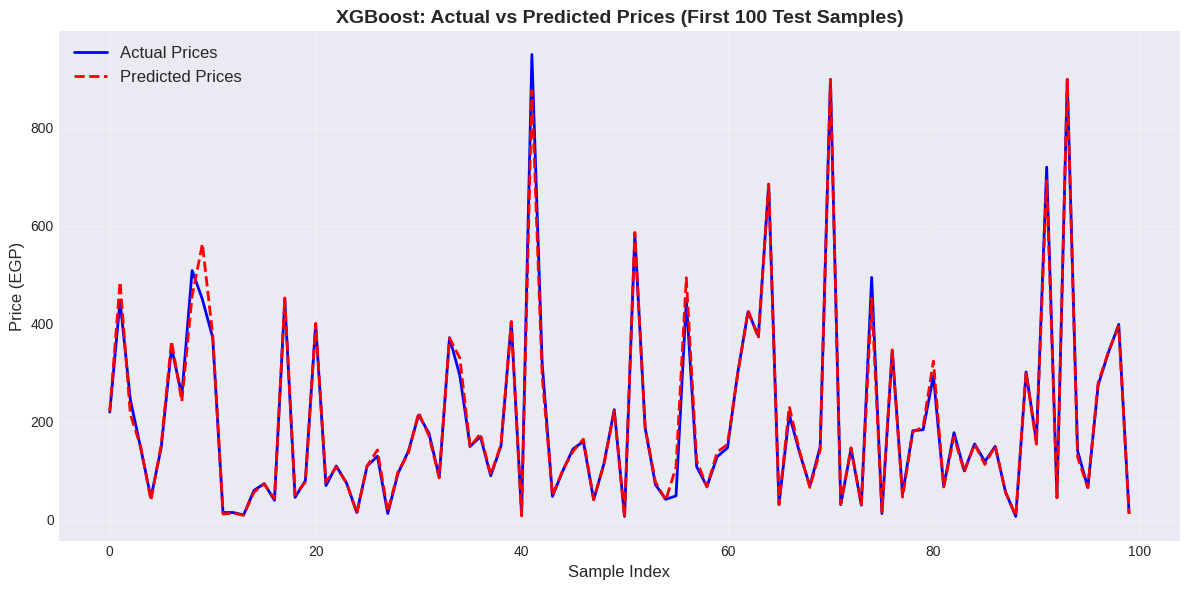

R2 Score: 0.9936
MAE: 6.62 EGP
RMSE: 14.58 EGP
MAPE: 6.15%


In [37]:
# Simple single plot
plt.figure(figsize=(12, 6))
plt.plot(y_test.values[:100], label='Actual Prices', linewidth=2, color='blue')
plt.plot(y_test_pred[:100], label='Predicted Prices', linewidth=2, color='red', linestyle='--')
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Price (EGP)', fontsize=12)
plt.title('XGBoost: Actual vs Predicted Prices (First 100 Test Samples)', fontsize=14, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('xgboost_simple_plot.png', dpi=300)
plt.show()

# Print metrics on the plot
print(f"R2 Score: {test_r2:.4f}")
print(f"MAE: {test_mae:.2f} EGP")
print(f"RMSE: {test_rmse:.2f} EGP")
print(f"MAPE: {test_mape:.2f}%")

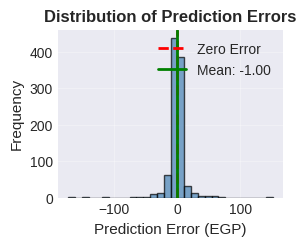

In [46]:
ax3 = plt.subplot(2, 2, 3)
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
plt.axvline(x=np.mean(residuals), color='green', linestyle='-', linewidth=2, label=f'Mean: {np.mean(residuals):.2f}')
plt.xlabel('Prediction Error (EGP)', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Distribution of Prediction Errors', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

In [47]:
from xgboost import XGBRegressor

model_with_loss = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.05,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1,
    eval_metric='rmse'
)


model_with_loss.fit(
    X_train_scaled, y_train,
    eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)],
    verbose=False
)


results = model_with_loss.evals_result()
train_loss = results['validation_0']['rmse']
val_loss = results['validation_1']['rmse']


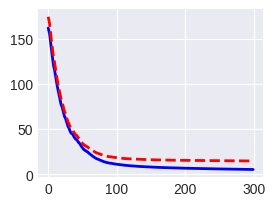

In [48]:
ax4 = plt.subplot(2, 2, 4)
epochs = len(train_loss)
x_axis = range(0, epochs)
plt.plot(x_axis, train_loss, label='Training RMSE', linewidth=2, color='blue')
plt.plot(x_axis, val_loss, label='Validation RMSE', linewidth=2, color='red', linestyle='--')

**LSTM Model**

In [49]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt


**Current Data but LSTM need 3D shape of data**

In [50]:
print(f"X_train_scaled shape (before reshape): {X_train_scaled.shape}")
print(f"X_test_scaled shape (before reshape): {X_test_scaled.shape}")


X_train_scaled shape (before reshape): (3904, 19)
X_test_scaled shape (before reshape): (977, 19)


In [51]:
X_train_lstm = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
X_test_lstm = X_test_scaled.reshape(X_test_scaled.shape[0], 1, X_test_scaled.shape[1])

In [52]:
print(f" X_train_lstm shape: {X_train_lstm.shape}")
print(f"   (samples={X_train_lstm.shape[0]}, timesteps={X_train_lstm.shape[1]}, features={X_train_lstm.shape[2]})")

print(f" X_test_lstm shape: {X_test_lstm.shape}")
print(f"   (samples={X_test_lstm.shape[0]}, timesteps={X_test_lstm.shape[1]}, features={X_test_lstm.shape[2]})")

 X_train_lstm shape: (3904, 1, 19)
   (samples=3904, timesteps=1, features=19)
 X_test_lstm shape: (977, 1, 19)
   (samples=977, timesteps=1, features=19)


**Build Model LSTM**

In [53]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input


lstm_model = Sequential([
    Input(shape=(1, 19)),
    LSTM(64, activation='tanh'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])


In [54]:
lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])


lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        21,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,617 (92.25 KB)

 Trainable params: 23,617 (92.25 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
history = lstm_model.fit(
    X_train_lstm, y_train,
    validation_data=(X_test_lstm, y_test),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 58345.4062 - mae: 172.1716 - val_loss: 62237.6484 - val_mae: 171.0559
Epoch 2/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 48772.1367 - mae: 147.1007 - val_loss: 43520.2227 - val_mae: 126.4378
Epoch 3/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 30670.8047 - mae: 110.6406 - val_loss: 30964.7148 - val_mae: 113.8806
Epoch 4/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 25286.8320 - mae: 107.4951 - val_loss: 28735.5176 - val_mae: 113.2789
Epoch 5/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 23635.4590 - mae: 104.0542 - val_loss: 26846.3672 - val_mae: 108.7358
Epoch 6/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 22324.5371 - mae: 100.0102 - val_loss: 24871.5605 - val_mae: 102.5651
Epoch 7/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 20679.7695 - mae: 93.2866 - val_loss: 22810.2695 - val_mae: 97.0311
Epoch 8/50
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 18893.5508 - mae: 87.9117 - 

In [56]:
y_test_pred_lstm = lstm_model.predict(X_test_lstm)
test_mae_lstm = mean_absolute_error(y_test, y_test_pred_lstm)
print(f"LSTM Test MAE: {test_mae_lstm:.2f} EGP")

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
LSTM Test MAE: 38.80 EGP


In [58]:

y_train_pred_lstm = lstm_model.predict(X_train_lstm)
y_test_pred_lstm = lstm_model.predict(X_test_lstm)

122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [59]:
print("Calculating predictions...")
y_train_pred_lstm = lstm_model.predict(X_train_lstm)
y_test_pred_lstm = lstm_model.predict(X_test_lstm)

Calculating predictions...
122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


**Some Calculations**

In [60]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


train_mae_lstm = mean_absolute_error(y_train, y_train_pred_lstm)
test_mae_lstm = mean_absolute_error(y_test, y_test_pred_lstm)
train_rmse_lstm = np.sqrt(mean_squared_error(y_train, y_train_pred_lstm))
test_rmse_lstm = np.sqrt(mean_squared_error(y_test, y_test_pred_lstm))
train_r2_lstm = r2_score(y_train, y_train_pred_lstm)
test_r2_lstm = r2_score(y_test, y_test_pred_lstm)

**Residuals**

In [61]:
residuals = y_test.values - y_test_pred_lstm.flatten()


In [62]:
print(" LSTM MODEL RESULTS")
print(f"R² Score - Training:  {train_r2_lstm:.4f}")
print(f"R² Score - Testing:   {test_r2_lstm:.4f}")
print(f"MAE - Training:  {train_mae_lstm:.2f} EGP")
print(f"MAE - Testing:   {test_mae_lstm:.2f} EGP")
print(f"RMSE - Training: {train_rmse_lstm:.2f} EGP")
print(f"RMSE - Testing:  {test_rmse_lstm:.2f} EGP")
print(f"Mean Residual (Bias): {np.mean(residuals):.4f} EGP")


 LSTM MODEL RESULTS
R² Score - Training:  0.8296
R² Score - Testing:   0.8417
MAE - Training:  36.31 EGP
MAE - Testing:   38.80 EGP
RMSE - Training: 70.01 EGP
RMSE - Testing:  72.57 EGP
Mean Residual (Bias): 2.9819 EGP


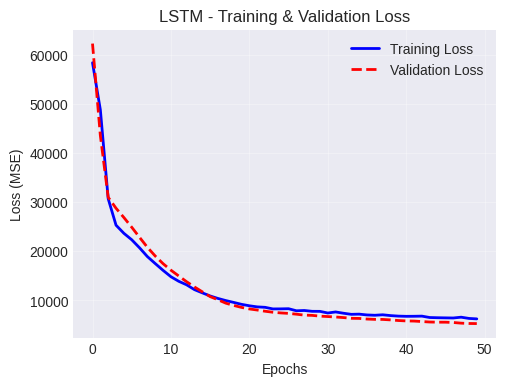

In [63]:
plt.figure(figsize=(12, 4))

# Loss Curve
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', linewidth=2, color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='red', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('LSTM - Training & Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)


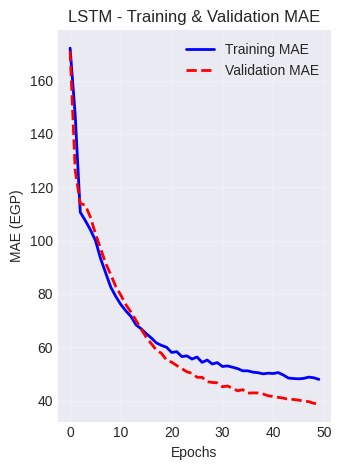

In [64]:
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE', linewidth=2, color='blue')
plt.plot(history.history['val_mae'], label='Validation MAE', linewidth=2, color='red', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('MAE (EGP)')
plt.title('LSTM - Training & Validation MAE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_loss_curve.png', dpi=300)
plt.show()

**Actual vs Predicted**

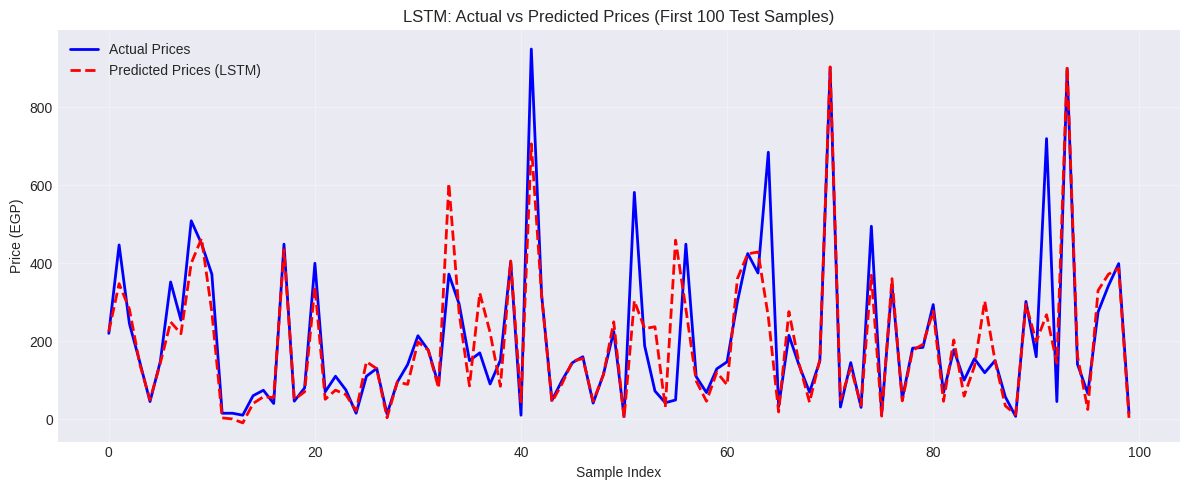

In [65]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:100], label='Actual Prices', linewidth=2, color='blue')
plt.plot(y_test_pred_lstm[:100], label='Predicted Prices (LSTM)', linewidth=2, color='red', linestyle='--')
plt.xlabel('Sample Index')
plt.ylabel('Price (EGP)')
plt.title('LSTM: Actual vs Predicted Prices (First 100 Test Samples)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lstm_actual_vs_predicted.png', dpi=300)
plt.show()

In [69]:

try:

    y_train_pred_lstm = lstm_model.predict(X_train_lstm)
    y_test_pred_lstm = lstm_model.predict(X_test_lstm)

    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    import numpy as np

    train_mae_lstm = mean_absolute_error(y_train, y_train_pred_lstm)
    test_mae_lstm = mean_absolute_error(y_test, y_test_pred_lstm)
    train_rmse_lstm = np.sqrt(mean_squared_error(y_train, y_train_pred_lstm))
    test_rmse_lstm = np.sqrt(mean_squared_error(y_test, y_test_pred_lstm))
    train_r2_lstm = r2_score(y_train, y_train_pred_lstm)
    test_r2_lstm = r2_score(y_test, y_test_pred_lstm)
    train_mape_lstm = np.mean(np.abs((y_train - y_train_pred_lstm.flatten()) / (y_train + 1e-8))) * 100
    test_mape_lstm = np.mean(np.abs((y_test - y_test_pred_lstm.flatten()) / (y_test + 1e-8))) * 100

    print(" LSTM results calculated successfully!")
    print(f"   LSTM Test MAE: {test_mae_lstm:.2f} EGP")
    print(f"   LSTM Test R²:  {test_r2_lstm:.4f}")

except NameError:
    print("LSTM model not found. Please train LSTM first.")
except Exception as e:
    print(f" Error: {e}")

122/122 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
 LSTM results calculated successfully!
   LSTM Test MAE: 38.80 EGP
   LSTM Test R²:  0.8417


In [73]:
from datetime import datetime
import json

In [74]:

lstm_results = {
    'Model': 'LSTM',
    'R2_Training': float(train_r2_lstm),
    'R2_Testing': float(test_r2_lstm),
    'MAE_Training': float(train_mae_lstm),
    'MAE_Testing': float(test_mae_lstm),
    'RMSE_Training': float(train_rmse_lstm),
    'RMSE_Testing': float(test_rmse_lstm),
    'MAPE_Training': float(train_mape_lstm),
    'MAPE_Testing': float(test_mape_lstm),
    'Timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

with open('lstm_results.json', 'w') as f:
    json.dump(lstm_results, f, indent=4)
print("\nSaved: lstm_results.json")


pd.DataFrame([lstm_results]).to_csv('lstm_results.csv', index=False)
print("Saved: lstm_results.csv")


lstm_predictions_df = pd.DataFrame({
    'Actual_Price': y_test.values,
    'LSTM_Predicted': y_test_pred_lstm.flatten(),
    'LSTM_Error': y_test.values - y_test_pred_lstm.flatten(),
    'LSTM_Absolute_Error': np.abs(y_test.values - y_test_pred_lstm.flatten()),
    'LSTM_Percentage_Error': np.abs((y_test.values - y_test_pred_lstm.flatten()) / (y_test.values + 1e-8)) * 100
})
lstm_predictions_df.to_csv('lstm_predictions.csv', index=False)
print(" Saved: lstm_predictions.csv")


history_df = pd.DataFrame({
    'Epoch': range(1, len(history.history['loss']) + 1),
    'Training_Loss': history.history['loss'],
    'Validation_Loss': history.history['val_loss'],
    'Training_MAE': history.history['mae'],
    'Validation_MAE': history.history['val_mae']
})
history_df.to_csv('lstm_training_history.csv', index=False)
print(" Saved: lstm_training_history.csv")


with open('lstm_results_summary.txt', 'w') as f:
    f.write("="*60 + "\n")
    f.write("LSTM MODEL RESULTS SUMMARY\n")
    f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write("="*60 + "\n\n")

    f.write("PERFORMANCE METRICS\n")
    f.write("-"*40 + "\n")
    f.write(f"R² Score (Training):  {train_r2_lstm:.4f} ({train_r2_lstm*100:.2f}%)\n")
    f.write(f"R² Score (Testing):   {test_r2_lstm:.4f} ({test_r2_lstm*100:.2f}%)\n")
    f.write(f"MAE (Training):       {train_mae_lstm:.2f} EGP\n")
    f.write(f"MAE (Testing):        {test_mae_lstm:.2f} EGP\n")
    f.write(f"RMSE (Training):      {train_rmse_lstm:.2f} EGP\n")
    f.write(f"RMSE (Testing):       {test_rmse_lstm:.2f} EGP\n")
    f.write(f"MAPE (Training):      {train_mape_lstm:.2f}%\n")
    f.write(f"MAPE (Testing):       {test_mape_lstm:.2f}%\n\n")

    f.write("MODEL ARCHITECTURE\n")
    f.write("-"*40 + "\n")
    f.write("Input shape: (1, 19)\n")
    f.write("LSTM Layer 1: 128 units, return_sequences=True, dropout=0.2\n")
    f.write("LSTM Layer 2: 64 units, return_sequences=False, dropout=0.2\n")
    f.write("Dense Layer 1: 32 units, ReLU, dropout=0.1\n")
    f.write("Dense Layer 2: 16 units, ReLU\n")
    f.write("Output Layer: 1 unit (linear)\n\n")

    f.write("TRAINING DETAILS\n")
    f.write("-"*40 + "\n")
    f.write(f"Total Epochs: {len(history.history['loss'])}\n")
    f.write(f"Final Training Loss: {history.history['loss'][-1]:.4f}\n")
    f.write(f"Final Validation Loss: {history.history['val_loss'][-1]:.4f}\n")
    f.write(f"Best Validation Loss: {min(history.history['val_loss']):.4f}\n")

print("Saved: lstm_results_summary.txt")


lstm_model.save('lstm_price_model.h5')



Saved: lstm_results.json
Saved: lstm_results.csv
 Saved: lstm_predictions.csv
 Saved: lstm_training_history.csv
Saved: lstm_results_summary.txt


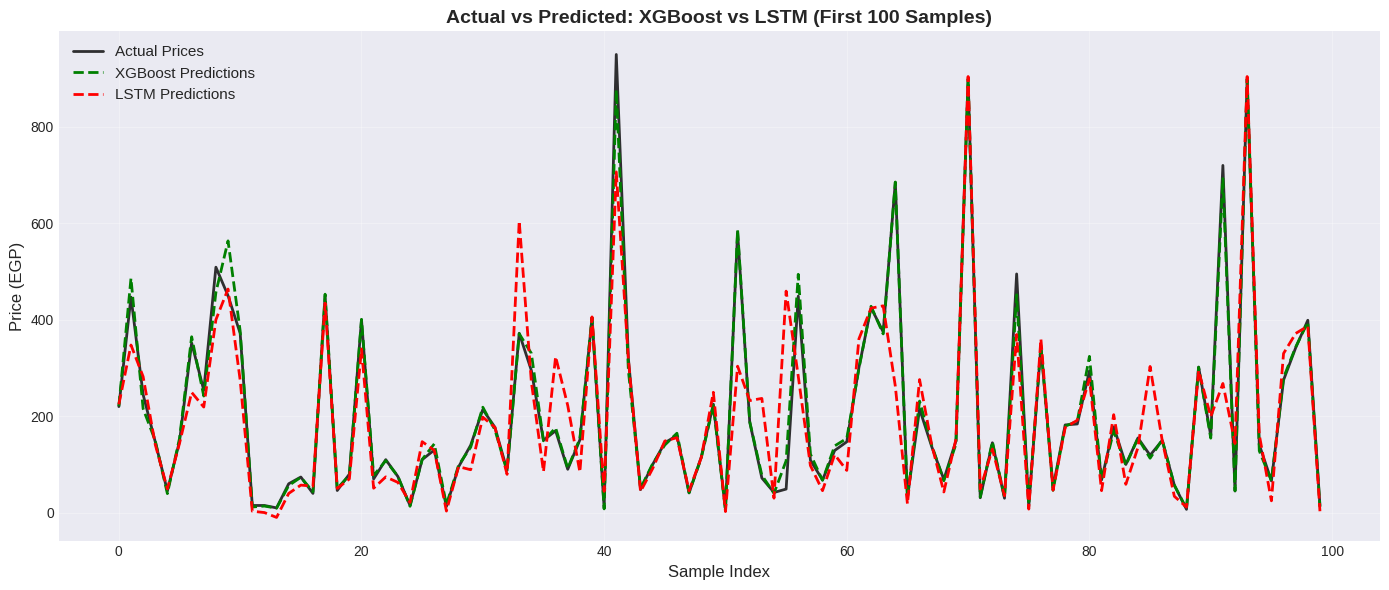

In [76]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14, 6))

plt.plot(y_test.values[:100], label='Actual Prices', linewidth=2, color='black', alpha=0.8)
plt.plot(y_test_pred[:100], label='XGBoost Predictions', linewidth=2, color='green', linestyle='--')
plt.plot(y_test_pred_lstm[:100], label='LSTM Predictions', linewidth=2, color='red', linestyle='--')

plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Price (EGP)', fontsize=12)
plt.title('Actual vs Predicted: XGBoost vs LSTM (First 100 Samples)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('xgboost_vs_lstm.png', dpi=300)
plt.show()